In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
df = pd.read_excel('Telco_customer_churn.xlsx')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

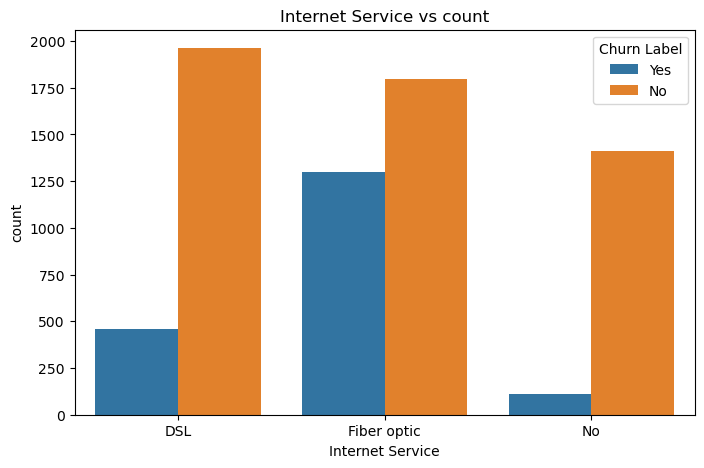

In [53]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service', hue='Churn Label', data=df)
plt.xlabel('Internet Service')
plt.ylabel('count')
plt.title('Internet Service vs count')
plt.show()

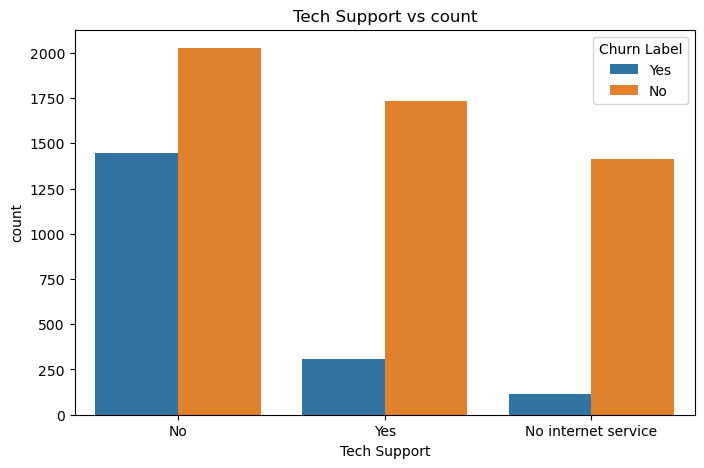

In [54]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support', hue='Churn Label', data=df)
plt.xlabel('Tech Support')
plt.ylabel('count')
plt.title('Tech Support vs count')
plt.show()

In [55]:
contract_churn = pd.crosstab(df['Contract'], df['Churn Label'], normalize='index')
contract_churn


Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


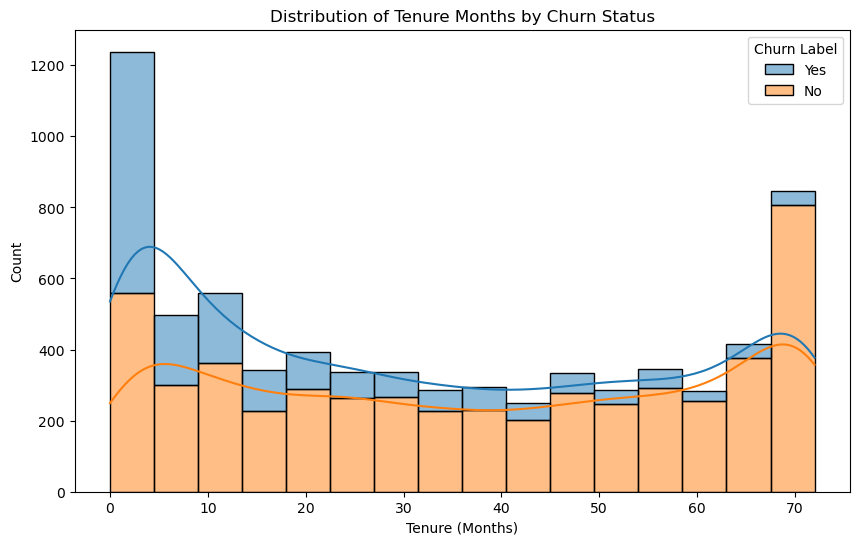

In [56]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Tenure Months', hue='Churn Label', multiple='stack', kde=True)
plt.title('Distribution of Tenure Months by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.show()

In [57]:
numerical_cols = ['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']
correlation_matrix = df[numerical_cols].corr()
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


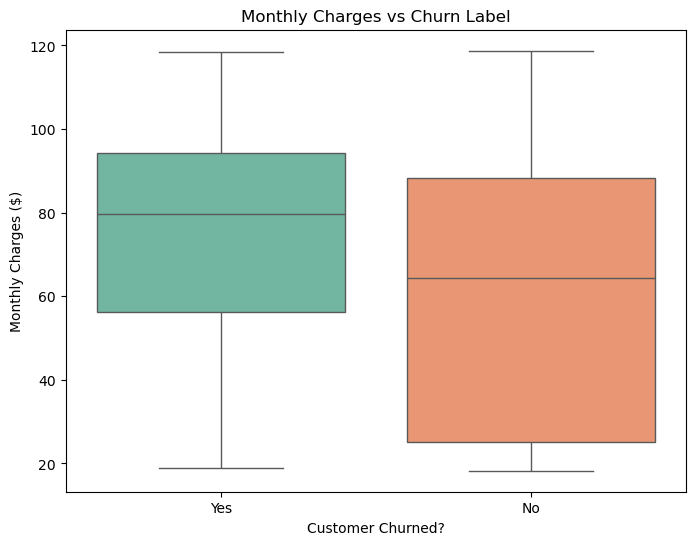

In [58]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Churn Label', y='Monthly Charges', hue='Churn Label', palette='Set2', legend=False)
plt.title('Monthly Charges vs Churn Label')
plt.xlabel('Customer Churned?')
plt.ylabel('Monthly Charges ($)')
plt.show()

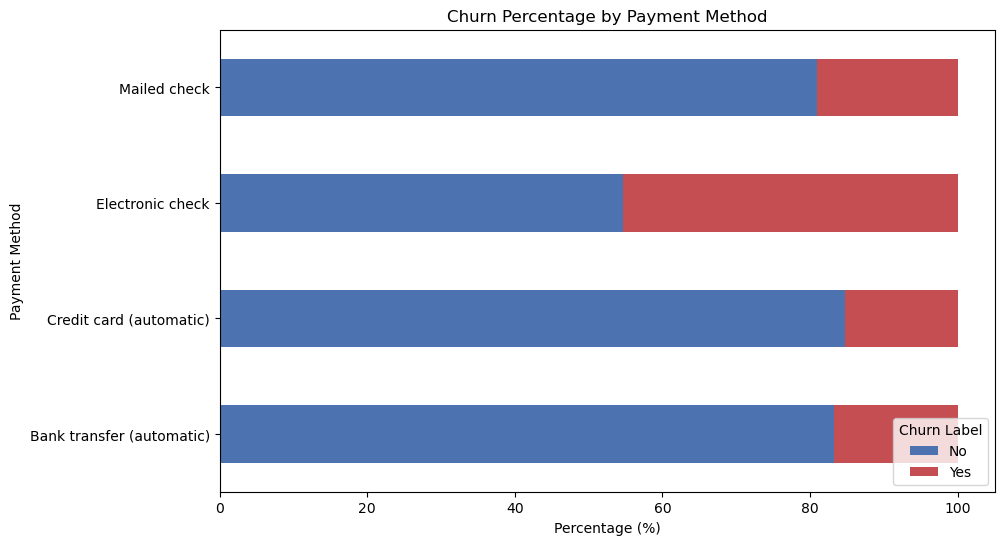

In [59]:
payment_churn = pd.crosstab(df['Payment Method'], df['Churn Label'], normalize='index') * 100

payment_churn.plot(kind='barh', stacked=True, figsize=(10, 6), color=['#4c72b0', '#c44e52'])
plt.title('Churn Percentage by Payment Method')
plt.xlabel('Percentage (%)')
plt.ylabel('Payment Method')
plt.legend(title='Churn Label', loc='lower right')
plt.show()

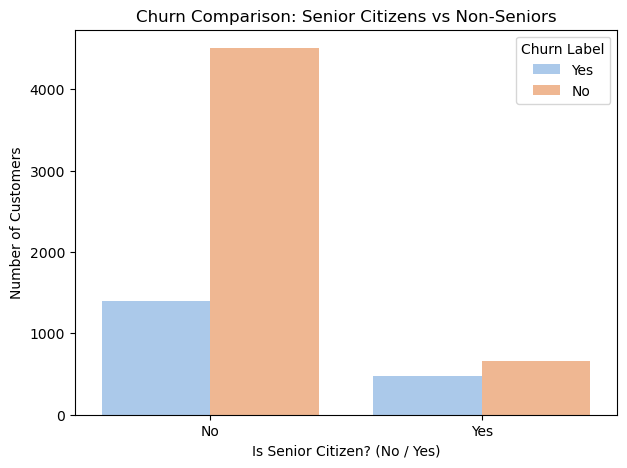

In [60]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Senior Citizen', hue='Churn Label', palette='pastel')
plt.title('Churn Comparison: Senior Citizens vs Non-Seniors')
plt.xlabel('Is Senior Citizen? (No / Yes)')
plt.ylabel('Number of Customers')
plt.show()

## Data Cleaning

In [61]:
# Total Charges is object dtype — convert to numeric
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
print(df['Total Charges'].dtype)
print('Null count:', df['Total Charges'].isnull().sum())

float64
Null count: 11


In [62]:
# All 11 null rows have Tenure Months = 0 (new customers, no charges yet)
print(df[df['Total Charges'].isnull()]['Tenure Months'])
print('Shape:', df[df['Total Charges'].isnull()]['Tenure Months'].shape)

2234    0
2438    0
2568    0
2667    0
2856    0
4331    0
4687    0
5104    0
5719    0
6772    0
6840    0
Name: Tenure Months, dtype: int64
Shape: (11,)


In [63]:
# Fill nulls with 0
df['Total Charges'] = df['Total Charges'].fillna(0)
print('Null count after fill:', df['Total Charges'].isnull().sum())

Null count after fill: 0


## Drop Irrelevant Columns

In [64]:
drop_columns = ['CustomerID', 'Count', 'Country', 'State', 'Zip Code',
                'Lat Long', 'Latitude', 'Longitude', 'Churn Label',
                'Churn Score', 'CLTV', 'Churn Reason', 'City']

df = df.drop(columns=drop_columns)
print(df.shape)  # should be (7043, 21)

(7043, 20)


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

## Encode Categorical Variables

In [66]:
df_encoded = pd.get_dummies(df, drop_first=True)
print(df_encoded.shape)

(7043, 31)


## Define Features (X) and Target (Y)

In [67]:
X = df_encoded.drop('Churn Value', axis=1)
Y = df_encoded['Churn Value']

print('X shape:', X.shape)
print('Y shape:', Y.shape)

X shape: (7043, 30)
Y shape: (7043,)


## Train-Test Split

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)
print('Y_train:', Y_train.shape)
print('Y_test: ', Y_test.shape)

X_train: (5634, 30)
X_test:  (1409, 30)
Y_train: (5634,)
Y_test:  (1409,)


## Baseline Random Forest Model

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(Y_test, y_pred)
print('Accuracy:', accuracy)

cm = confusion_matrix(Y_test, y_pred)
print('Confusion Matrix:\n', cm)

print(classification_report(Y_test, y_pred))

Accuracy: 0.7856635911994322
Confusion Matrix:
 [[902 107]
 [195 205]]
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



## Approach 1 - Handle Class Imbalance

In [70]:
rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_balanced.fit(X_train, Y_train)

y_pred_balanced = rf_balanced.predict(X_test)

accuracy_balanced = accuracy_score(Y_test, y_pred_balanced)
cm_balanced = confusion_matrix(Y_test, y_pred_balanced)

print('Accuracy (Balanced):', accuracy_balanced)
print('Confusion Matrix:\n', cm_balanced)
print(classification_report(Y_test, y_pred_balanced))

Accuracy (Balanced): 0.7920511000709723
Confusion Matrix:
 [[907 102]
 [191 209]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



## Approach 2 - Hyperparameter Tuning

In [71]:
rf_tuned = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf_tuned.fit(X_train, Y_train)

y_pred_tuned = rf_tuned.predict(X_test)

accuracy_tuned = accuracy_score(Y_test, y_pred_tuned)
cm_tuned = confusion_matrix(Y_test, y_pred_tuned)

print('Accuracy (Tuned):', accuracy_tuned)
print('Confusion Matrix:\n', cm_tuned)
print(classification_report(Y_test, y_pred_tuned))

Accuracy (Tuned): 0.7828246983676366
Confusion Matrix:
 [[804 205]
 [101 299]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



## Approach 3 - Feature Importance Analysis

In [72]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Features': X.columns,
    'Importance': rf_tuned.feature_importances_
})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

                                  Features  Importance
0                            Tenure Months    0.179069
2                            Total Charges    0.136460
25                       Contract_Two year    0.102861
1                          Monthly Charges    0.093681
6                           Dependents_Yes    0.068517
10            Internet Service_Fiber optic    0.060228
28         Payment Method_Electronic check    0.046732
24                       Contract_One year    0.036682
13                     Online Security_Yes    0.029356
19                        Tech Support_Yes    0.021106
26                   Paperless Billing_Yes    0.018064
5                              Partner_Yes    0.015846
12     Online Security_No internet service    0.014973
18        Tech Support_No internet service    0.014799
22    Streaming Movies_No internet service    0.014360
16   Device Protection_No internet service    0.012985
11                     Internet Service_No    0.012673
3         

In [73]:
print(feature_importance.tail(15))

                                  Features  Importance
16   Device Protection_No internet service    0.012985
11                     Internet Service_No    0.012673
3                              Gender_Male    0.012586
15                       Online Backup_Yes    0.012213
9                       Multiple Lines_Yes    0.011690
14       Online Backup_No internet service    0.010298
4                       Senior Citizen_Yes    0.010257
20        Streaming TV_No internet service    0.010186
23                    Streaming Movies_Yes    0.010161
27  Payment Method_Credit card (automatic)    0.009430
21                        Streaming TV_Yes    0.009289
17                   Device Protection_Yes    0.009101
29             Payment Method_Mailed check    0.008800
7                        Phone Service_Yes    0.003872
8          Multiple Lines_No phone service    0.003725


<Figure size 1000x600 with 0 Axes>

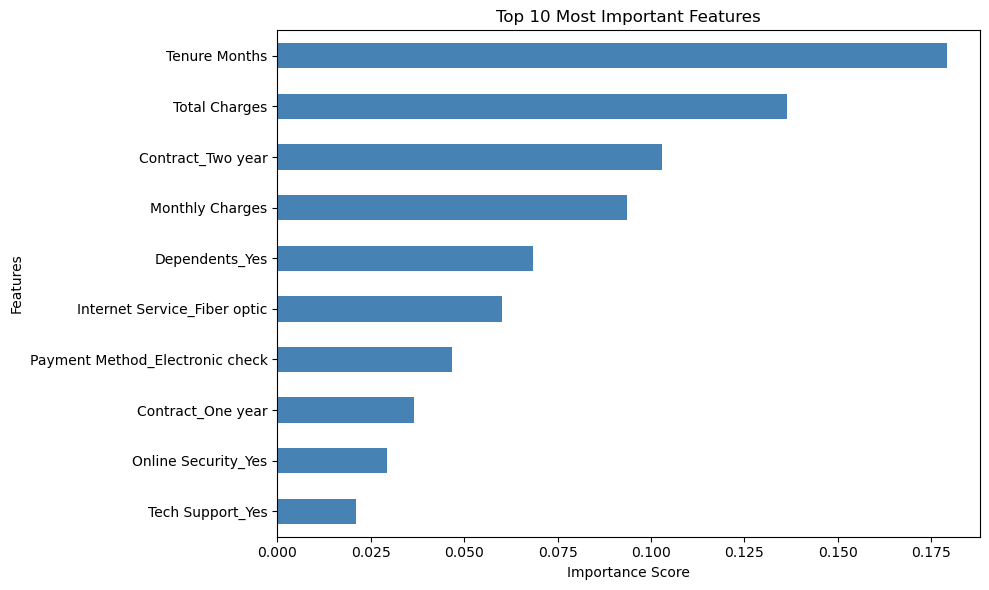

In [74]:
# Feature Importance Bar Chart — Top 10
plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='barh', x='Features',
                                  y='Importance', figsize=(10,6),
                                  color='steelblue', legend=False)
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [75]:
# Drop least important features
X_selected = X.drop(['Phone Service_Yes', 'Multiple Lines_No phone service'], axis=1)

X_train_sel, X_test_sel, Y_train_sel, Y_test_sel = train_test_split(
    X_selected, Y, test_size=0.2, random_state=42
)

rf_selected = RandomForestClassifier(n_estimators=300, max_depth=10,
                                      random_state=42, class_weight='balanced')
rf_selected.fit(X_train_sel, Y_train_sel)
y_pred_selected = rf_selected.predict(X_test_sel)

print(classification_report(Y_test_sel, y_pred_selected))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.60      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



## Confusion Matrix Heatmap

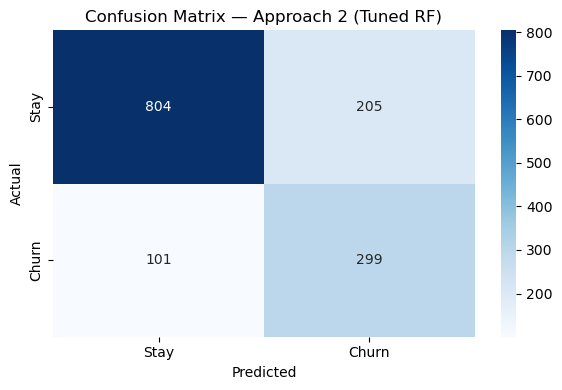

In [76]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay','Churn'],
            yticklabels=['Stay','Churn'])
plt.title('Confusion Matrix — Approach 2 (Tuned RF)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Churn Distribution

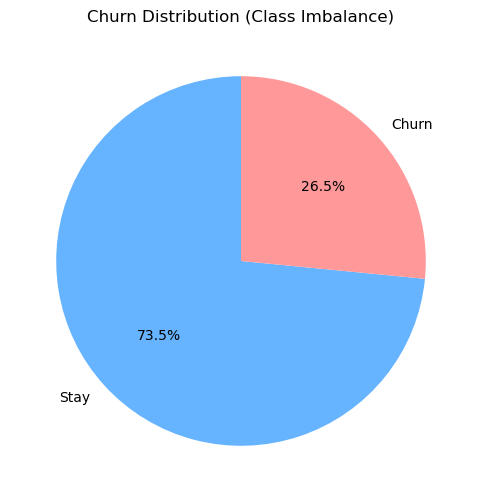

In [77]:
plt.figure(figsize=(6,6))
Y.value_counts().plot(kind='pie', autopct='%1.1f%%',
                      colors=['#66b3ff','#ff9999'],
                      labels=['Stay','Churn'],
                      startangle=90)
plt.title('Churn Distribution (Class Imbalance)')
plt.ylabel('')
plt.show()

## Hyperparameter Grid Search

In [78]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

n_estimators_list = [100, 200, 300, 400, 500]
max_depth_list    = [5, 10, 15, 20]
results = []

for n_trees in n_estimators_list:
    for depth in max_depth_list:
        rf = RandomForestClassifier(n_estimators=n_trees, max_depth=depth,
                                    random_state=42, class_weight='balanced')
        rf.fit(X_train, Y_train)
        y_pred = rf.predict(X_test)
        accuracy  = accuracy_score(Y_test, y_pred)
        recall    = recall_score(Y_test, y_pred)
        precision = precision_score(Y_test, y_pred)
        f1        = f1_score(Y_test, y_pred)
        results.append({'Trees': n_trees, 'Depth': depth,
                        'Accuracy': accuracy, 'Recall': recall,
                        'Precision': precision, 'F1 Score': f1})

result_df = pd.DataFrame(results)
result_df = result_df.sort_values(by=['Recall','Accuracy'], ascending=False)
print(result_df.head(20))

    Trees  Depth  Accuracy  Recall  Precision  F1 Score
0     100      5  0.745919  0.8200   0.534202  0.646943
8     300      5  0.743790  0.8200   0.531605  0.645034
12    400      5  0.743790  0.8125   0.531915  0.642928
4     200      5  0.742370  0.8100   0.530278  0.640950
16    500      5  0.740951  0.8050   0.528736  0.638256
1     100     10  0.775727  0.7525   0.581081  0.655773
9     300     10  0.782825  0.7475   0.593254  0.661504
13    400     10  0.782825  0.7475   0.593254  0.661504
17    500     10  0.781405  0.7475   0.590909  0.660044
5     200     10  0.782115  0.7450   0.592445  0.660022
10    300     15  0.806246  0.6400   0.664935  0.652229
14    400     15  0.803407  0.6375   0.658915  0.648030
18    500     15  0.801987  0.6375   0.655527  0.646388
6     200     15  0.804826  0.6350   0.663185  0.648787
2     100     15  0.802697  0.6300   0.659686  0.644501
3     100     20  0.787793  0.5325   0.655385  0.587586
7     200     20  0.793471  0.5275   0.674121  0

## Model Comparison Table

In [79]:
from sklearn.metrics import recall_score, precision_score, f1_score

models_comparison = pd.DataFrame({
    'Model': ['Baseline RF', 'Approach 1 (Balanced)', 'Approach 2 (Tuned)'],
    'Accuracy':  [
        round(accuracy_score(Y_test, y_pred), 3),
        round(accuracy_balanced, 3),
        round(accuracy_tuned, 3)
    ],
    'Recall': [
        round(recall_score(Y_test, y_pred), 3),
        round(recall_score(Y_test, y_pred_balanced), 3),
        round(recall_score(Y_test, y_pred_tuned), 3)
    ],
    'Precision': [
        round(precision_score(Y_test, y_pred), 3),
        round(precision_score(Y_test, y_pred_balanced), 3),
        round(precision_score(Y_test, y_pred_tuned), 3)
    ],
    'F1 Score': [
        round(f1_score(Y_test, y_pred), 3),
        round(f1_score(Y_test, y_pred_balanced), 3),
        round(f1_score(Y_test, y_pred_tuned), 3)
    ]
})
print(models_comparison.to_string(index=False))

                Model  Accuracy  Recall  Precision  F1 Score
          Baseline RF     0.788   0.520      0.660     0.582
Approach 1 (Balanced)     0.792   0.522      0.672     0.588
   Approach 2 (Tuned)     0.783   0.748      0.593     0.662


## Cross Validation

In [80]:
from sklearn.model_selection import cross_val_score

final_rf = RandomForestClassifier(n_estimators=300, max_depth=10,
                                   random_state=42, class_weight='balanced')

cv_accuracy = cross_val_score(final_rf, X, Y, cv=5, scoring='accuracy')
print('CV Accuracy scores:', cv_accuracy)
print('CV Accuracy mean:  ', cv_accuracy.mean())

CV Accuracy scores: [0.76721079 0.79772889 0.76224273 0.78551136 0.78409091]
CV Accuracy mean:   0.7793569343183432


In [81]:
cv_recall = cross_val_score(final_rf, X, Y, cv=5, scoring='recall')
print('CV Recall scores:', cv_recall)
print('CV Recall mean:  ', cv_recall.mean())

CV Recall scores: [0.70855615 0.76470588 0.74064171 0.74331551 0.71045576]
CV Recall mean:   0.7335350030823931


## OPTIONAL - ROC AUC Curve

AUC Score: 0.857104806739346


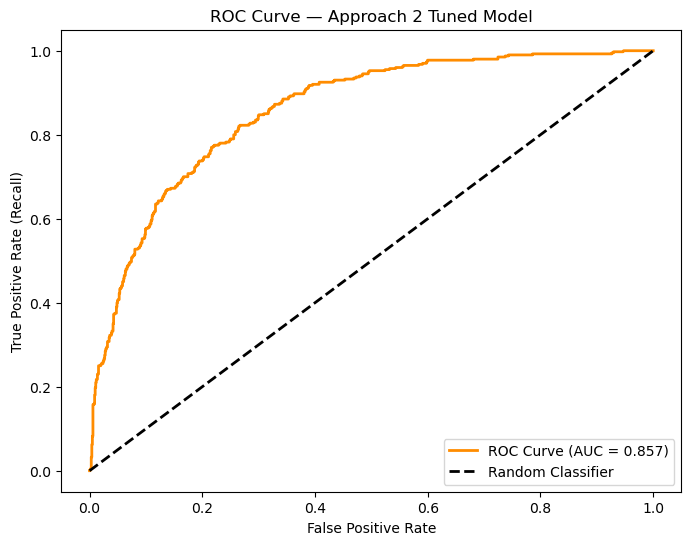

In [82]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob1 = rf_tuned.predict_proba(X_test)
churn_prob = y_prob1[:, 1]

fpr, tpr, threshold = roc_curve(Y_test, churn_prob)
auc_score = roc_auc_score(Y_test, churn_prob)
print('AUC Score:', auc_score)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0,1],[0,1],'k--', lw=2, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Approach 2 Tuned Model')
plt.legend(loc='lower right')
plt.show()

## Approach 4 - SMOTE

In [84]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_smote, Y_smote = smote.fit_resample(X_train, Y_train)

print('Before SMOTE:', Y_train.value_counts().to_dict())
print('After SMOTE: ', pd.Series(Y_smote).value_counts().to_dict())

Before SMOTE: {0: 4165, 1: 1469}
After SMOTE:  {0: 4165, 1: 4165}


In [85]:
rf_smote = RandomForestClassifier(n_estimators=300, max_depth=10,
                                   random_state=42)
rf_smote.fit(X_smote, Y_smote)
y_pred_smote = rf_smote.predict(X_test)

print('Accuracy:', accuracy_score(Y_test, y_pred_smote))
print('Recall:  ', recall_score(Y_test, y_pred_smote))
print(classification_report(Y_test, y_pred_smote))

Accuracy: 0.7885024840312278
Recall:   0.7075
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1009
           1       0.61      0.71      0.66       400

    accuracy                           0.79      1409
   macro avg       0.74      0.76      0.75      1409
weighted avg       0.80      0.79      0.79      1409



## Learning Curve (Check Overfitting/Underfitting)

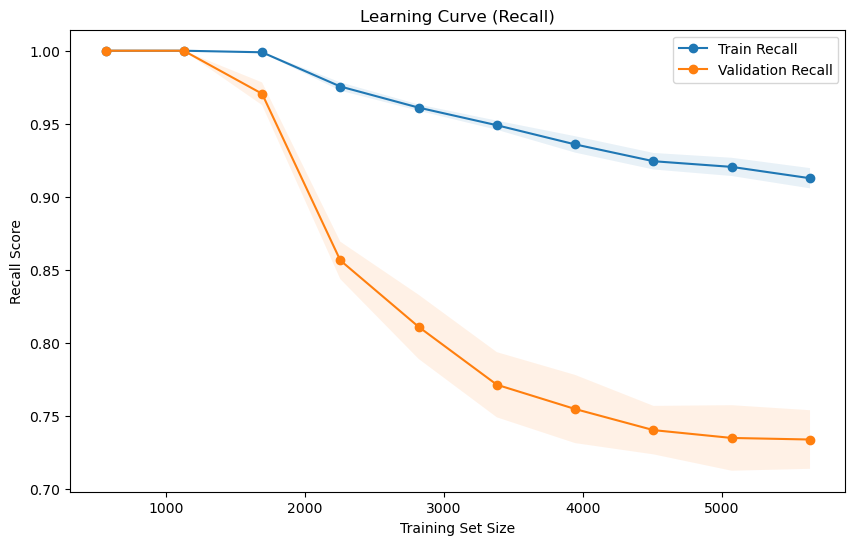

In [86]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    final_rf, X, Y, cv=5, scoring='recall',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train Recall')
plt.plot(train_sizes, val_scores.mean(axis=1),   'o-', label='Validation Recall')
plt.fill_between(train_sizes,
    train_scores.mean(axis=1) - train_scores.std(axis=1),
    train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1)
plt.fill_between(train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1)
plt.title('Learning Curve (Recall)')
plt.xlabel('Training Set Size')
plt.ylabel('Recall Score')
plt.legend()
plt.show()

## Customer Segmentation using KMeans Clustering

In [87]:
y_prob_full = rf_tuned.predict_proba(X)
churn_probability = y_prob_full[:, 1]

segmentation_data = pd.DataFrame({
    'Tenure Months':     X['Tenure Months'].values,
    'Monthly Charges':   X['Monthly Charges'].values,
    'Total Charges':     X['Total Charges'].values,
    'Churn Probability': churn_probability
})
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.676963
1,2,70.70,151.65,0.796013
2,8,99.65,820.50,0.805827
3,28,104.80,3046.05,0.563031
4,49,103.70,5036.30,0.517474
...,...,...,...,...
7038,72,21.15,1419.40,0.003587
7039,24,84.80,1990.50,0.082095
7040,72,103.20,7362.90,0.049001
7041,11,29.60,346.45,0.302367


## Implementation of KMeans

In [88]:
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

scaler = StandardScaler()
scaled_data = scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.9580659   1.02486837]
 [-1.23672422  0.19736523 -0.93887444  1.4138535 ]
 [-0.99240204  1.1595457  -0.64378925  1.44591771]
 [-0.17799476  1.33071079  0.3380854   0.65260685]
 [ 0.67713287  1.29415125  1.2161497   0.50375182]]


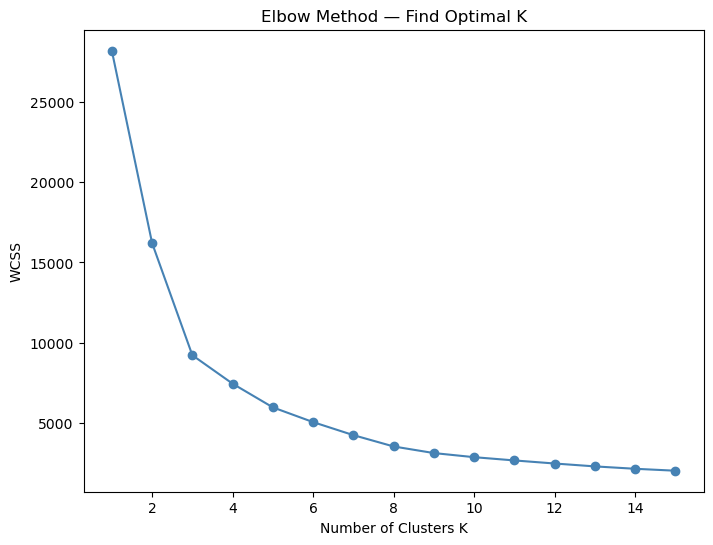

In [89]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 16):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 16), wcss, marker='o', color='steelblue')
plt.xlabel('Number of Clusters K')
plt.ylabel('WCSS')
plt.title('Elbow Method — Find Optimal K')
plt.show()

In [90]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

segmentation_data['Cluster'] = clusters
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
0,2,53.85,108.15,0.676963,0
1,2,70.70,151.65,0.796013,0
2,8,99.65,820.50,0.805827,0
3,28,104.80,3046.05,0.563031,0
4,49,103.70,5036.30,0.517474,2
...,...,...,...,...,...
7038,72,21.15,1419.40,0.003587,1
7039,24,84.80,1990.50,0.082095,1
7040,72,103.20,7362.90,0.049001,2
7041,11,29.60,346.45,0.302367,1


In [91]:
cluster_summary = segmentation_data.groupby('Cluster').mean()
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Cluster,,,,
0,11.020858,72.552794,892.239906,0.694955
1,31.515825,32.709324,1025.165141,0.126263
2,58.365065,90.242860,5264.395102,0.229958


In [92]:
cluster_names = {
    0: 'Budget Loyal Customers',
    1: 'High Risk New Customers',
    2: 'Loyal Premium Customers'
}

segmentation_data['Cluster Segment'] = segmentation_data['Cluster'].map(cluster_names)
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segment
0,2,53.85,108.15,0.676963,0,Budget Loyal Customers
1,2,70.70,151.65,0.796013,0,Budget Loyal Customers
2,8,99.65,820.50,0.805827,0,Budget Loyal Customers
3,28,104.80,3046.05,0.563031,0,Budget Loyal Customers
4,49,103.70,5036.30,0.517474,2,Loyal Premium Customers
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.003587,1,High Risk New Customers
7039,24,84.80,1990.50,0.082095,1,High Risk New Customers
7040,72,103.20,7362.90,0.049001,2,Loyal Premium Customers
7041,11,29.60,346.45,0.302367,1,High Risk New Customers


## Cluster Visualizations

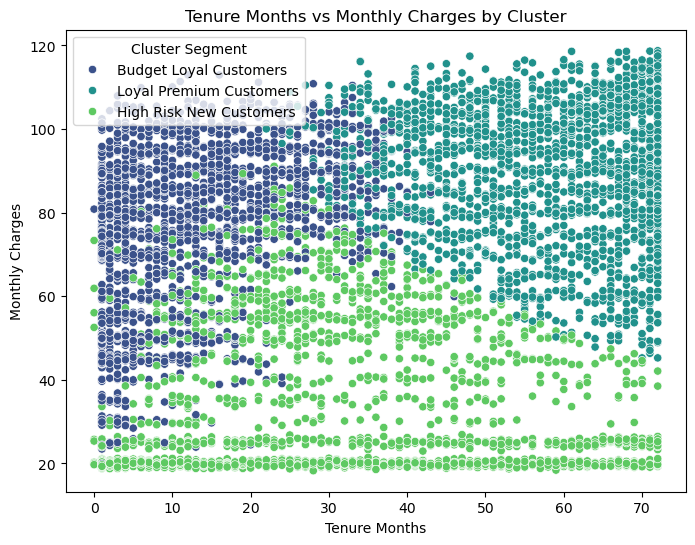

In [93]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Tenure Months', y='Monthly Charges',
                hue='Cluster Segment', data=segmentation_data, palette='viridis')
plt.title('Tenure Months vs Monthly Charges by Cluster')
plt.show()

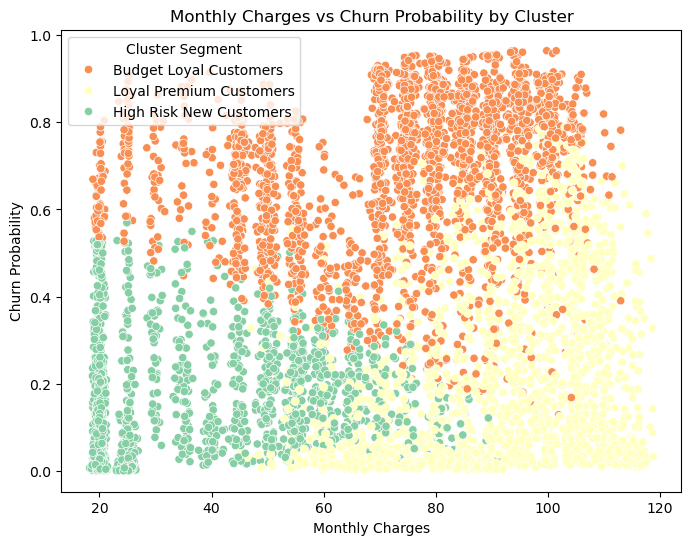

In [94]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Monthly Charges', y='Churn Probability',
                hue='Cluster Segment', data=segmentation_data, palette='Spectral')
plt.title('Monthly Charges vs Churn Probability by Cluster')
plt.show()

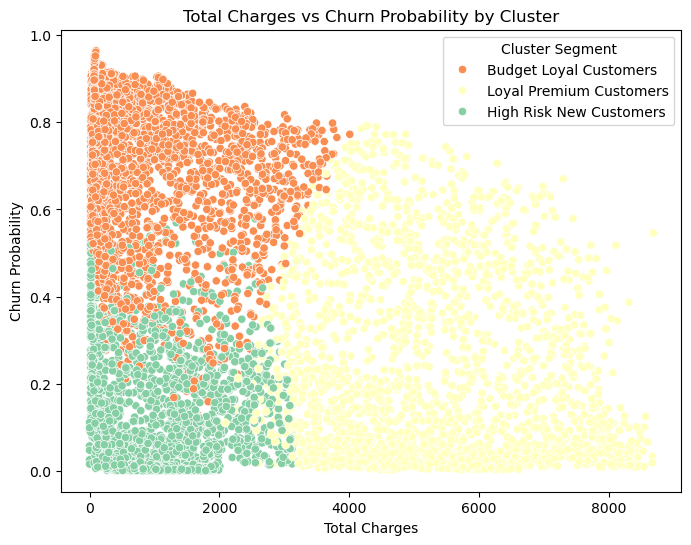

In [95]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Total Charges', y='Churn Probability',
                hue='Cluster Segment', data=segmentation_data, palette='Spectral')
plt.title('Total Charges vs Churn Probability by Cluster')
plt.show()

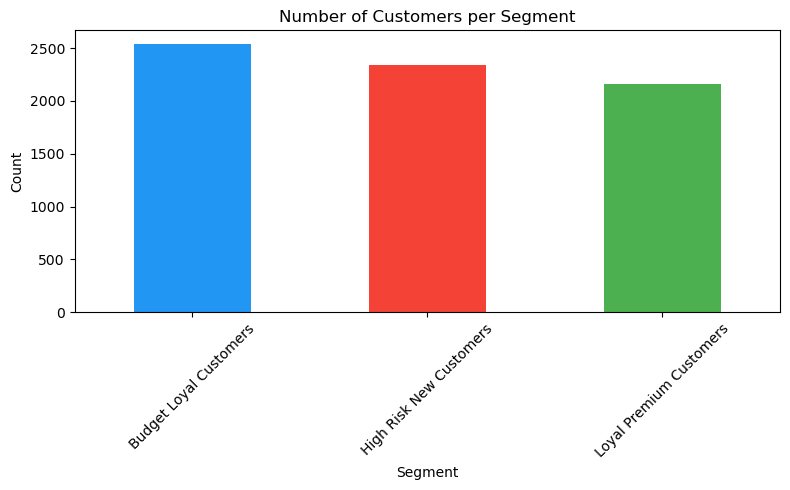

In [96]:
plt.figure(figsize=(8,5))
segmentation_data['Cluster Segment'].value_counts().plot(
    kind='bar', color=['#2196F3','#F44336','#4CAF50'])
plt.title('Number of Customers per Segment')
plt.ylabel('Count')
plt.xlabel('Segment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

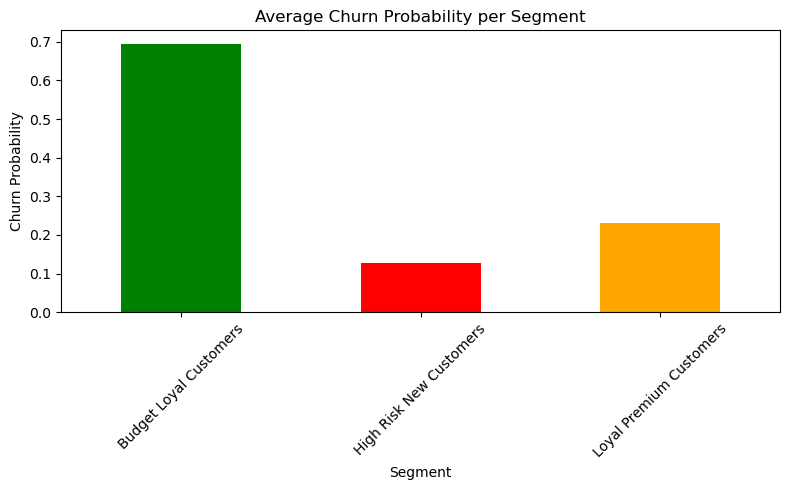

In [97]:
plt.figure(figsize=(8,5))
cluster_churn = segmentation_data.groupby('Cluster Segment')['Churn Probability'].mean()
cluster_churn.plot(kind='bar', color=['green','red','orange'])
plt.title('Average Churn Probability per Segment')
plt.ylabel('Churn Probability')
plt.xlabel('Segment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Business Impact Analysis

In [ ]:
total_customers  = len(Y_test)
actual_churners  = int(Y_test.sum())
caught_churners  = int(((y_pred_tuned == 1) & (Y_test == 1)).sum())
missed_churners  = actual_churners - caught_churners
false_alarms     = int(((y_pred_tuned == 1) & (Y_test == 0)).sum())

revenue_per_customer = 65  # average monthly charge

print('=' * 45)
print('       BUSINESS IMPACT ANALYSIS')
print('=' * 45)
print(f'Total test customers      : {total_customers}')
print(f'Actual churners           : {actual_churners}')
print(f'Churners caught by model  : {caught_churners}')
print(f'Churners missed           : {missed_churners}')
print(f'False alarms              : {false_alarms}')
print('─' * 45)
print(f'Potential revenue saved   : ${caught_churners * revenue_per_customer:,}/month')
print(f'Revenue still at risk     : ${missed_churners * revenue_per_customer:,}/month')
print('=' * 45)

## Retention Strategy per Segment

In [ ]:
strategy = pd.DataFrame({
    'Segment':     ['High Risk New', 'Budget Loyal', 'Loyal Premium'],
    'Churn Risk':  ['~69%',          '~12%',         '~23%'],
    'Action':      ['Immediate call + discount offer',
                    'Loyalty reward points',
                    'VIP service + exclusive perks'],
    'Priority':    ['HIGH',           'LOW',          'MEDIUM']
})
print(strategy.to_string(index=False))